# LTV Paper-Figure Analogues for March 18

This notebook regenerates current-data analogues of Figs. 1, 4, 5, 7, 8, 9, and 10 from Petz & Kochanek (2025) for the reviewed March 18 LTV sample.

These are not exact reconstructions of the paper's full ASAS-SN parent-sample figures. They use the local March 18 review bundle, local ASAS-SN variable catalog, and cached NEOWISE light curves only. No network queries are performed.


## Setup

In [1]:

from __future__ import annotations

import json
import os
import sqlite3
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/malca-mplconfig")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "malca").is_dir():
            return candidate
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "malca").is_dir():
            return candidate
    raise RuntimeError(f"Could not find repo root from {start}")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from malca.catalogs.neowise_filters import filter_neowise_single_exposure_lc
from malca.config import (
    LTV_DUST_COLOR_EXCESS_THRESH,
    LTV_DUST_COLOR_SLOPE_THRESH,
    LTV_DUST_OPTICAL_SLOPE_THRESH,
)
from malca.ltv.neowise import combine_epochs, fit_neowise_trends
from malca.plotting.lightcurve_publication import (
    apply_publication_rcparams,
    filter_lightcurve,
    load_lightcurve,
    plot_lightcurve_panel,
    save_publication_figure,
)

apply_publication_rcparams(plt)

RUN_ROOT = REPO_ROOT / "output" / "runs" / "runs_march18_bundle_all"
CANDIDATES_PATH = RUN_ROOT / "results" / "lc_events_classified.parquet"
REVIEW_DB = RUN_ROOT / "review" / "review.taxonomy_filled.db"
LIGHTCURVE_DIR = RUN_ROOT / "bundle_assets" / "lightcurves"
RESULTS_DIR = RUN_ROOT / "results"
NEOWISE_DIR = RESULTS_DIR
ASASSN_VARIABLES_PATH = REPO_ROOT / "input" / "asassn_variables_220326.csv"
OUT_DIR = RESULTS_DIR / "ltv_paper_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional manual overrides. Leave empty for deterministic automatic choices.
FIG7_EXAMPLE_IDS: list[str] = []
FIG10_EXAMPLE_IDS: list[str] = []

CLASS_ORDER = ["SR", "L", "ROT"]
CLASS_COLORS = {"SR": "#4C78A8", "L": "#F58518", "ROT": "#54A24B"}
LTV_COLOR = "#C43C39"
COMPARISON_COLOR = "0.55"

SUMMARY: dict[str, object] = {
    "run_root": str(RUN_ROOT.relative_to(REPO_ROOT)),
    "candidate_table": str(CANDIDATES_PATH.relative_to(REPO_ROOT)),
    "review_db": str(REVIEW_DB.relative_to(REPO_ROOT)),
    "output_dir": str(OUT_DIR.relative_to(REPO_ROOT)),
    "figures": {},
    "caveats": [
        "Current-data analogues only; not exact reconstructions of the full Petz & Kochanek parent sample.",
        "No network fetches are performed; missing Gaia/WISE/catalog data are reported and skipped.",
    ],
}

print(f"repo root: {REPO_ROOT}")
print(f"run root : {RUN_ROOT}")
print(f"out dir  : {OUT_DIR}")


/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo root: /Users/calder/code/malca
run root : /Users/calder/code/malca/output/runs/runs_march18_bundle_all
out dir  : /Users/calder/code/malca/output/runs/runs_march18_bundle_all/results/ltv_paper_figures


## Data Loading

In [2]:

def json_frame(series: pd.Series, prefix: str) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for value in series:
        if isinstance(value, str) and value.strip():
            try:
                parsed = json.loads(value)
            except json.JSONDecodeError:
                parsed = {}
        elif isinstance(value, dict):
            parsed = value
        else:
            parsed = {}
        rows.append(parsed if isinstance(parsed, dict) else {})
    out = pd.DataFrame(rows, index=series.index)
    if out.empty:
        return out
    return out.add_prefix(prefix)


def numeric_col(df: pd.DataFrame, col: str) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.nan, index=df.index, dtype="float64")
    return pd.to_numeric(df[col], errors="coerce")


def positive_uncertainty(series: pd.Series) -> pd.Series:
    out = pd.to_numeric(series, errors="coerce")
    return out.where(np.isfinite(out) & (out > 0))


def combine_uncertainties(*series: pd.Series) -> pd.Series:
    if not series:
        return pd.Series(dtype="float64")
    first = pd.to_numeric(series[0], errors="coerce")
    total = pd.Series(0.0, index=first.index, dtype="float64")
    seen = pd.Series(False, index=first.index)
    for item in series:
        err = positive_uncertainty(item).reindex(first.index)
        ok = np.isfinite(err)
        total = total.add(err.where(ok, 0.0) ** 2, fill_value=0.0)
        seen = seen | ok
    out = np.sqrt(total)
    return out.where(seen & np.isfinite(out) & (out > 0))


def absolute_mag_uncertainty(
    g_mag: pd.Series,
    parallax_mas: pd.Series,
    parallax_err_mas: pd.Series,
    *,
    g_err: pd.Series | None = None,
    distance_pc: pd.Series | None = None,
    distance_err_pc: pd.Series | None = None,
) -> pd.Series:
    g = pd.to_numeric(g_mag, errors="coerce")
    index = g.index
    g_sigma = pd.Series(0.0, index=index, dtype="float64") if g_err is None else positive_uncertainty(g_err).reindex(index).fillna(0.0)
    parallax = pd.to_numeric(parallax_mas, errors="coerce").reindex(index)
    parallax_err = positive_uncertainty(parallax_err_mas).reindex(index)
    frac_dist = pd.Series(np.nan, index=index, dtype="float64")

    use_parallax = (parallax > 0) & (parallax_err > 0)
    frac_dist.loc[use_parallax] = parallax_err.loc[use_parallax] / parallax.loc[use_parallax]

    if distance_pc is not None and distance_err_pc is not None:
        dist = pd.to_numeric(distance_pc, errors="coerce").reindex(index)
        dist_err = positive_uncertainty(distance_err_pc).reindex(index)
        use_dist = ~use_parallax & (dist > 0) & (dist_err > 0)
        frac_dist.loc[use_dist] = dist_err.loc[use_dist] / dist.loc[use_dist]

    distance_modulus_sigma = (5.0 / np.log(10.0)) * frac_dist
    out = np.sqrt(g_sigma**2 + distance_modulus_sigma**2)
    return out.where(np.isfinite(out) & (out > 0))


def observed_mg(g_mag: pd.Series, parallax_mas: pd.Series, distance_pc: pd.Series) -> pd.Series:
    g = pd.to_numeric(g_mag, errors="coerce")
    plx = pd.to_numeric(parallax_mas, errors="coerce")
    dist = pd.to_numeric(distance_pc, errors="coerce")
    use_plx = plx > 0
    out_dist = dist.where(dist > 0)
    out_dist = out_dist.where(~use_plx, 1000.0 / plx.where(use_plx))
    mg = g - 5.0 * np.log10(out_dist) + 5.0
    return mg.where(np.isfinite(mg))


def add_canonical_columns(flat: pd.DataFrame) -> pd.DataFrame:
    out = flat.copy()
    out["optical_slope"] = numeric_col(out, "lc.stats_trend_slope_mag_per_year")
    out["optical_slope_err"] = numeric_col(out, "lc.stats_trend_slope_err_mag_per_year")
    out["delta_mag"] = numeric_col(out, "lc.stats_delta_mag_fid")
    out["period_days"] = numeric_col(out, "lc.stats_variability_lomb_scargle_best_period_days")
    out["period_fap"] = numeric_col(out, "lc.stats_variability_lomb_scargle_fap")

    raw_color = numeric_col(out, "derived.bp_rp")
    dered_color = numeric_col(out, "derived.bprp0")
    g = numeric_col(out, "external.phot_g_mean_mag")
    parallax = numeric_col(out, "external.parallax")
    dist = numeric_col(out, "external.distance_gspphot")
    raw_mag = observed_mg(g, parallax, dist)
    dered_mag = numeric_col(out, "derived.mg0")

    out["cmd_color"] = dered_color.where(np.isfinite(dered_color), raw_color)
    out["cmd_mag"] = dered_mag.where(np.isfinite(dered_mag), raw_mag)
    out["cmd_coordinate_source"] = np.where(
        np.isfinite(dered_color) & np.isfinite(dered_mag),
        "dereddened",
        np.where(np.isfinite(raw_color) & np.isfinite(raw_mag), "observed", "missing"),
    )
    out["cmd_color_err"] = pd.Series(np.nan, index=out.index, dtype="float64")
    out["cmd_mag_err"] = absolute_mag_uncertainty(
        g,
        parallax,
        numeric_col(out, "external.parallax_error"),
        g_err=numeric_col(out, "external.e_phot_g_mean_mag"),
        distance_pc=dist,
    ).where(np.isfinite(out["cmd_mag"]))
    return out


def flatten_candidate_table(candidates: pd.DataFrame) -> pd.DataFrame:
    base_cols = [
        "candidate_id",
        "asas_sn_id",
        "lc_path",
        "source_path",
        "catalog_class",
        "catalog_period",
        "period_vsx_class",
        "period_asassn_var_class",
        "period_ztf_periodic_class",
        "period_gaia_eb_class",
    ]
    base = candidates[[col for col in base_cols if col in candidates.columns]].copy()
    base["candidate_id"] = base["candidate_id"].astype("string")
    for col in ("lc_stats", "external_stats", "derived_stats"):
        if col not in candidates.columns:
            candidates[col] = None
    pieces = [
        base,
        json_frame(candidates["lc_stats"], "lc."),
        json_frame(candidates["external_stats"], "external."),
        json_frame(candidates["derived_stats"], "derived."),
    ]
    flat = pd.concat(pieces, axis=1)
    return add_canonical_columns(flat)


candidates = pd.read_parquet(CANDIDATES_PATH)
all_flat = flatten_candidate_table(candidates)

with sqlite3.connect(REVIEW_DB) as conn:
    reviews = pd.read_sql_query(
        """
        SELECT
            candidate_id,
            event_class,
            interest_score,
            workflow_status,
            status,
            morphology_primary,
            morphology_secondary,
            physical_primary,
            physical_secondary,
            updated_at
        FROM reviews
        WHERE workflow_status = 'reviewed' OR status = 'reviewed'
        """,
        conn,
    ).astype({"candidate_id": "string"})

reviewed = all_flat.merge(reviews, on="candidate_id", how="inner")
ltv = reviewed[reviewed["event_class"].astype("string").str.lower().eq("ltv")].copy()

asas_vars = pd.read_csv(ASASSN_VARIABLES_PATH)
asas_vars = asas_vars[(asas_vars["Mean_gmag"] > 13.0) & (asas_vars["Mean_gmag"] < 14.5)].copy()

SUMMARY["n_all_candidates"] = int(len(all_flat))
SUMMARY["n_reviewed_candidates"] = int(len(reviewed))
SUMMARY["n_ltv_candidates"] = int(len(ltv))
SUMMARY["n_asassn_variables_13_14p5"] = int(len(asas_vars))

print(f"all March 18 candidates: {len(all_flat):,}")
print(f"reviewed candidates      : {len(reviewed):,}")
print(f"reviewed LTV candidates  : {len(ltv):,}")
print(f"ASAS-SN variable catalog : {len(asas_vars):,} rows with 13 < g < 14.5")


all March 18 candidates: 9,569
reviewed candidates      : 1,407
reviewed LTV candidates  : 39
ASAS-SN variable catalog : 119,595 rows with 13 < g < 14.5


## Shared Helpers

In [3]:

def save_figure(fig, name: str, table: pd.DataFrame | None = None, *, dpi: int = 220) -> dict[str, object]:
    png_path = OUT_DIR / f"{name}.png"
    pdf_path = OUT_DIR / f"{name}.pdf"
    csv_path = OUT_DIR / f"{name}.csv"
    save_publication_figure(fig, png_path, dpi=dpi, close=False, facecolor="white")
    fig.savefig(pdf_path, bbox_inches=None, facecolor="white")
    if table is None:
        table = pd.DataFrame()
    table.to_csv(csv_path, index=False)
    display(Image(filename=str(png_path)))
    plt.close(fig)
    result = {
        "png": str(png_path.relative_to(REPO_ROOT)),
        "pdf": str(pdf_path.relative_to(REPO_ROOT)),
        "csv": str(csv_path.relative_to(REPO_ROOT)),
        "table_rows": int(len(table)),
    }
    SUMMARY["figures"][name] = result
    return result


def record_caveat(figure: str, message: str) -> None:
    entry = SUMMARY.setdefault("figures", {}).setdefault(figure, {})
    caveats = entry.setdefault("caveats", [])
    if message not in caveats:
        caveats.append(message)


def plot_hist_with_count_uncertainty(
    ax,
    values: pd.Series,
    bins: np.ndarray,
    *,
    hist_kwargs: dict[str, object],
    error_color: str | None = None,
    error_alpha: float = 0.75,
):
    finite = pd.to_numeric(pd.Series(values), errors="coerce")
    finite = finite[np.isfinite(finite)]
    counts, edges, patches = ax.hist(finite.to_numpy(dtype=float), bins=bins, **hist_kwargs)
    counts = np.asarray(counts, dtype=float)
    edges = np.asarray(edges, dtype=float)
    if counts.size:
        centers = np.sqrt(edges[:-1] * edges[1:]) if np.all(edges[:-1] > 0) else 0.5 * (edges[:-1] + edges[1:])
        ok = counts > 0
        if ok.any():
            ax.errorbar(
                centers[ok],
                counts[ok],
                yerr=np.sqrt(counts[ok]),
                fmt="none",
                ecolor=error_color or str(hist_kwargs.get("color", "black")),
                elinewidth=0.65,
                capsize=1.2,
                capthick=0.65,
                alpha=error_alpha,
                zorder=4,
            )
    return counts, edges, patches


def scatter_with_uncertainty(
    ax,
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
    *,
    xerr_col: str | None = None,
    yerr_col: str | None = None,
    scatter_kwargs: dict[str, object] | None = None,
    errorbar_kwargs: dict[str, object] | None = None,
):
    if data.empty:
        return None
    x = pd.to_numeric(data[x_col], errors="coerce")
    y = pd.to_numeric(data[y_col], errors="coerce")
    ok = np.isfinite(x) & np.isfinite(y)
    if not ok.any():
        return None
    plot_df = data.loc[ok].copy()
    x = x.loc[ok]
    y = y.loc[ok]

    xerr = None
    if xerr_col is not None and xerr_col in plot_df.columns:
        candidate = positive_uncertainty(plot_df[xerr_col]).to_numpy(dtype=float)
        xerr = candidate if np.isfinite(candidate).any() else None
    yerr = None
    if yerr_col is not None and yerr_col in plot_df.columns:
        candidate = positive_uncertainty(plot_df[yerr_col]).to_numpy(dtype=float)
        yerr = candidate if np.isfinite(candidate).any() else None

    scatter_kwargs = dict(scatter_kwargs or {})
    if xerr is not None or yerr is not None:
        err_kwargs = {
            "fmt": "none",
            "ecolor": "0.35",
            "elinewidth": 0.65,
            "capsize": 1.2,
            "capthick": 0.65,
            "alpha": 0.8,
            "zorder": scatter_kwargs.get("zorder", 3),
        }
        if errorbar_kwargs:
            err_kwargs.update(errorbar_kwargs)
        ax.errorbar(x, y, xerr=xerr, yerr=yerr, **err_kwargs)
    return ax.scatter(x, y, **scatter_kwargs)


def linear_slope_standard_error(time_days: pd.Series, value: pd.Series, value_error: pd.Series | None = None) -> float:
    t = pd.to_numeric(pd.Series(time_days), errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(pd.Series(value), errors="coerce").to_numpy(dtype=float)
    err = np.full_like(y, np.nan, dtype=float)
    if value_error is not None:
        err = positive_uncertainty(pd.Series(value_error)).to_numpy(dtype=float)
    ok = np.isfinite(t) & np.isfinite(y)
    if ok.sum() < 3:
        return np.nan
    t = t[ok]
    y = y[ok]
    err = err[ok]
    x = (t - np.nanmedian(t)) / 365.25

    has_err = np.isfinite(err) & (err > 0)
    if has_err.sum() >= max(3, int(np.ceil(0.5 * len(y)))):
        fill = float(np.nanmedian(err[has_err]))
        err = np.where(has_err, err, fill)
        weights = 1.0 / np.square(err)
        weighted = True
    else:
        weights = np.ones_like(y)
        weighted = False

    sw = float(np.sum(weights))
    sx = float(np.sum(weights * x))
    sy = float(np.sum(weights * y))
    sxx = float(np.sum(weights * x * x))
    sxy = float(np.sum(weights * x * y))
    denom = sw * sxx - sx * sx
    if denom <= 0:
        return np.nan
    slope = (sw * sxy - sx * sy) / denom
    intercept = (sxx * sy - sx * sxy) / denom
    resid = y - (slope * x + intercept)
    dof = max(len(y) - 2, 1)
    if weighted:
        scale = max(float(np.sum(weights * resid * resid) / dof), 1.0)
    else:
        scale = float(np.sum(resid * resid) / dof)
    slope_var = scale * sw / denom
    return float(np.sqrt(slope_var)) if np.isfinite(slope_var) and slope_var > 0 else np.nan


def median_measurement_uncertainty(errors: pd.Series) -> float:
    err = positive_uncertainty(pd.Series(errors)).dropna().to_numpy(dtype=float)
    if len(err) == 0:
        return np.nan
    return float(1.253314 * np.sqrt(np.nanmean(err**2)) / np.sqrt(len(err)))


def normalize_variable_class(value: object) -> str | None:
    if value is None or pd.isna(value):
        return None
    text = str(value).strip().upper()
    if not text or text in {"NAN", "NONE", "NULL"}:
        return None
    text = text.replace(":", "").replace("?", "")
    if text == "ROT" or text.startswith("ROT") or text in {"BY", "BYDRA", "ACV", "SPOTTED"}:
        return "ROT"
    if text == "SR" or text.startswith("SR") or text in {"SRA", "SRB", "SRC", "SRD"}:
        return "SR"
    if text == "L" or text in {"LB", "LC", "LSP", "LPV"} or text.startswith("L "):
        return "L"
    return None


CLASS_SOURCE_COLUMNS = [
    "catalog_class",
    "period_vsx_class",
    "period_asassn_var_class",
    "period_ztf_periodic_class",
    "period_gaia_eb_class",
    "external.vsx_class",
    "external.gaia_var_class",
    "external.asassn_var_type",
    "external.simbad_otype",
]


def add_known_class(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    classes: list[str | None] = []
    sources: list[str | None] = []
    for _, row in out.iterrows():
        chosen = None
        chosen_source = None
        for col in CLASS_SOURCE_COLUMNS:
            if col not in row.index:
                continue
            normalized = normalize_variable_class(row.get(col))
            if normalized is not None:
                chosen = normalized
                chosen_source = col
                break
        classes.append(chosen)
        sources.append(chosen_source)
    out["known_var_class"] = pd.Series(classes, index=out.index, dtype="string")
    out["known_var_class_source"] = pd.Series(sources, index=out.index, dtype="string")
    return out


all_flat = add_known_class(all_flat)
reviewed = add_known_class(reviewed)
ltv = add_known_class(ltv)


def asassn_catalog_cmd(catalog: pd.DataFrame) -> pd.DataFrame:
    out = catalog.copy()
    out["known_var_class"] = out["ML_classification"].map(normalize_variable_class).astype("string")
    g = pd.to_numeric(out.get("phot_g_mean_mag"), errors="coerce")
    g = g.where(np.isfinite(g), pd.to_numeric(out.get("Mean_gmag"), errors="coerce"))
    bp_rp = pd.to_numeric(out.get("bp_rp"), errors="coerce")
    parallax = pd.to_numeric(out.get("parallax"), errors="coerce")
    dist = pd.to_numeric(out.get("EDR3_dist"), errors="coerce")
    out["cmd_color"] = bp_rp
    out["cmd_color_err"] = combine_uncertainties(
        numeric_col(out, "e_phot_bp_mean_mag"),
        numeric_col(out, "e_phot_rp_mean_mag"),
    )
    out["cmd_mag"] = observed_mg(g, parallax, dist)
    out["cmd_mag_err"] = absolute_mag_uncertainty(
        g,
        parallax,
        numeric_col(out, "parallax_error"),
        g_err=numeric_col(out, "e_phot_g_mean_mag"),
        distance_pc=dist,
    ).where(np.isfinite(out["cmd_mag"]))
    return out


asas_cmd = asassn_catalog_cmd(asas_vars)
asas_cmd = asas_cmd[asas_cmd["known_var_class"].isin(CLASS_ORDER)].copy()


def candidate_lc_path(candidate_id: object) -> Path:
    return LIGHTCURVE_DIR / f"{str(candidate_id)}.dat3"


def load_asassn_lc(candidate_id: object) -> pd.DataFrame:
    path = candidate_lc_path(candidate_id)
    lc = load_lightcurve(path)
    df = filter_lightcurve(lc, bands=None, max_error=1.0)
    return df.sort_values("time").reset_index(drop=True)


def fit_linear_detrend(lc: pd.DataFrame) -> tuple[pd.DataFrame, tuple[float, float]]:
    df = lc.copy()
    time = pd.to_numeric(df["time"], errors="coerce").to_numpy(dtype=float)
    mag = pd.to_numeric(df["value"], errors="coerce").to_numpy(dtype=float)
    ok = np.isfinite(time) & np.isfinite(mag)
    if ok.sum() < 2:
        df["trend_mag"] = np.nan
        df["detrended_mag"] = np.nan
        return df, (np.nan, np.nan)
    t0 = np.nanmedian(time[ok])
    slope, intercept = np.polyfit(time[ok] - t0, mag[ok], 1)
    trend = slope * (time - t0) + intercept
    df["trend_mag"] = trend
    df["detrended_mag"] = mag - trend
    return df, (float(slope), float(intercept))


def phase_fold_lc(lc: pd.DataFrame, period_days: float) -> pd.DataFrame:
    df = lc.copy()
    time = pd.to_numeric(df["time"], errors="coerce")
    phase = ((time - time.min()) / float(period_days)) % 1.0
    df["phase"] = phase
    doubled = pd.concat([df, df.assign(phase=phase + 1.0)], ignore_index=True)
    return doubled.sort_values("phase").reset_index(drop=True)


def neowise_lc_path(candidate_id: object) -> Path:
    return NEOWISE_DIR / f"neowise_lc_{str(candidate_id)}.parquet"


def load_neowise_epochs(candidate_id: object) -> tuple[pd.DataFrame, dict[str, object]]:
    path = neowise_lc_path(candidate_id)
    if not path.exists():
        return pd.DataFrame(), {
            "ltv_neowise_w1_slope": np.nan,
            "ltv_neowise_w1_w2_slope": np.nan,
            "ltv_neowise_w1_w2_median": np.nan,
            "ltv_neowise_n_epochs": 0,
            "neowise_status": "missing_file",
        }
    raw = pd.read_parquet(path).sort_values("mjd").reset_index(drop=True)
    filtered = filter_neowise_single_exposure_lc(raw)
    epochs = combine_epochs(filtered)
    if epochs.empty:
        return epochs, {
            "ltv_neowise_w1_slope": np.nan,
            "ltv_neowise_w1_w2_slope": np.nan,
            "ltv_neowise_w1_w2_median": np.nan,
            "ltv_neowise_n_epochs": 0,
            "neowise_status": "empty_after_filter",
        }
    trends = fit_neowise_trends(epochs)
    trends["neowise_status"] = "ok"
    return epochs, trends


def build_neowise_metrics(cohort: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    metric_rows: list[dict[str, object]] = []
    epoch_rows: list[pd.DataFrame] = []
    for _, row in cohort.iterrows():
        cid = str(row["candidate_id"])
        epochs, trends = load_neowise_epochs(cid)
        optical_slope_err = row.get("optical_slope_err", np.nan)
        if not np.isfinite(pd.to_numeric(pd.Series([optical_slope_err]), errors="coerce").iloc[0]) and candidate_lc_path(cid).exists():
            try:
                asassn_lc = load_asassn_lc(cid)
                optical_slope_err = linear_slope_standard_error(asassn_lc["time"], asassn_lc["value"], asassn_lc.get("value_error"))
            except Exception:
                optical_slope_err = np.nan

        w1w2_epoch_err = pd.Series(np.nan, index=epochs.index, dtype="float64")
        if not epochs.empty:
            w1w2_epoch_err = combine_uncertainties(epochs["w1err"], epochs["w2err"])
            epochs = epochs.copy()
            epochs["w1_w2_err"] = w1w2_epoch_err

        metric = {
            "candidate_id": cid,
            "optical_slope": row.get("optical_slope"),
            "optical_slope_err": optical_slope_err,
            "cmd_color": row.get("cmd_color"),
            "cmd_color_err": row.get("cmd_color_err"),
            "cmd_mag": row.get("cmd_mag"),
            "cmd_mag_err": row.get("cmd_mag_err"),
            "w1_slope_err": linear_slope_standard_error(epochs["mjd"], epochs["w1mpro"], epochs["w1err"]) if not epochs.empty else np.nan,
            "w1w2_slope_err": linear_slope_standard_error(epochs["mjd"], epochs["w1_w2"], w1w2_epoch_err) if not epochs.empty else np.nan,
            "w1w2_median_err": median_measurement_uncertainty(w1w2_epoch_err) if not epochs.empty else np.nan,
            **trends,
        }
        metric_rows.append(metric)
        if not epochs.empty:
            ep = epochs.copy()
            ep["candidate_id"] = cid
            ep["plot_time"] = pd.to_numeric(ep["mjd"], errors="coerce") - 50000.0
            epoch_rows.append(ep)
    metrics = pd.DataFrame(metric_rows)
    epoch_table = pd.concat(epoch_rows, ignore_index=True) if epoch_rows else pd.DataFrame()
    return metrics, epoch_table


neowise_metrics, neowise_epochs_all = build_neowise_metrics(ltv)

SUMMARY["n_ltv_known_sr_l_rot"] = int(ltv["known_var_class"].isin(CLASS_ORDER).sum())
SUMMARY["n_ltv_neowise_files"] = int((neowise_metrics["neowise_status"] != "missing_file").sum())
SUMMARY["n_ltv_neowise_ok"] = int((neowise_metrics["neowise_status"] == "ok").sum())

print("known LTV SR/L/ROT classes:")
print(ltv["known_var_class"].value_counts(dropna=False).to_string())
print("NEOWISE status:")
print(neowise_metrics["neowise_status"].value_counts(dropna=False).to_string())


known LTV SR/L/ROT classes:
known_var_class
<NA>    34
ROT      4
SR       1
NEOWISE status:
neowise_status
ok              31
missing_file     8


## Fig. 1 Analogue: Selection Histograms

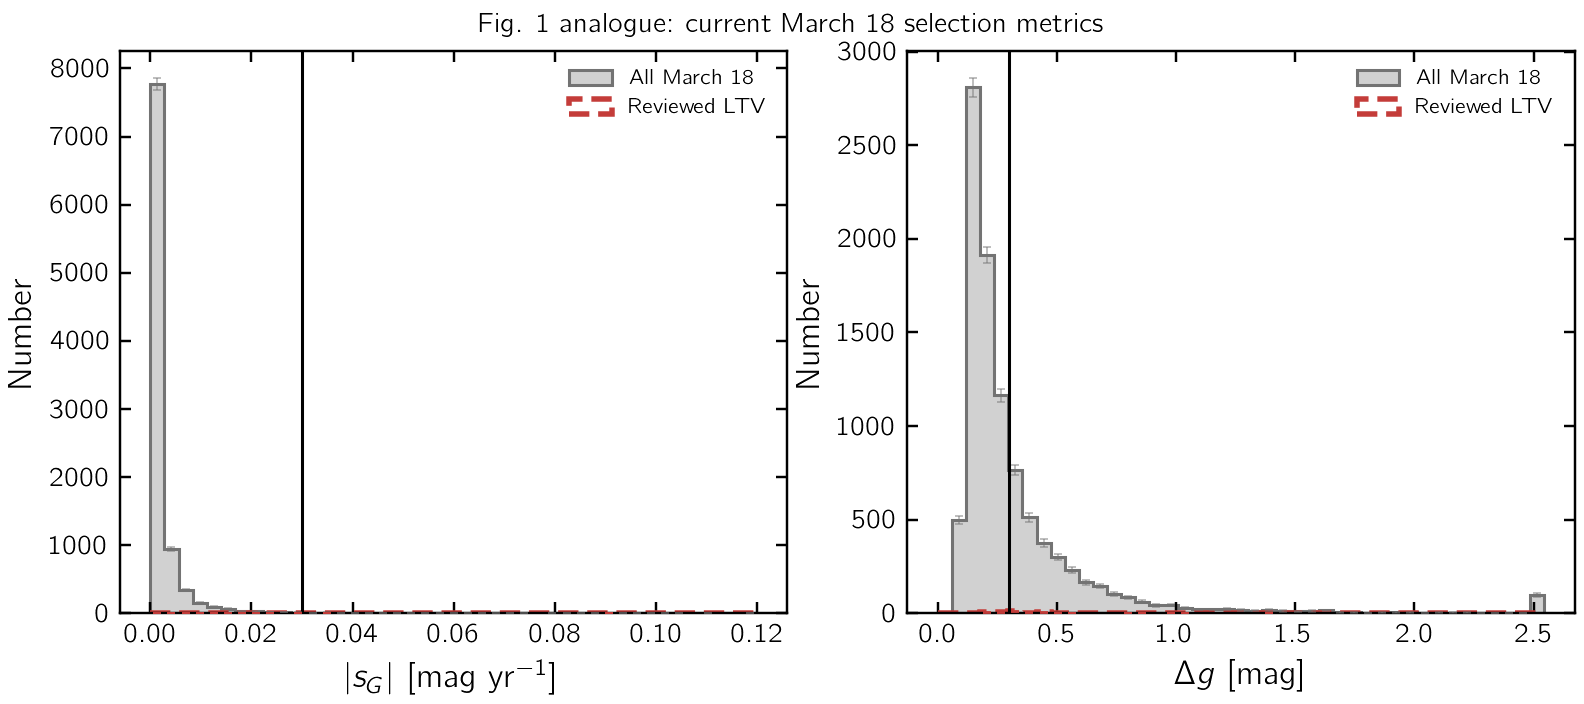

{'png': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig01_ltv_selection_histograms.png',
 'pdf': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig01_ltv_selection_histograms.pdf',
 'csv': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig01_ltv_selection_histograms.csv',
 'table_rows': 9608,
 'n_all_with_slope': 9569,
 'n_ltv_with_slope': 39,
 'caveats': ['Background is all current March 18 candidates, not the original 9.36M input-source parent sample.']}

In [4]:

fig1_name = "fig01_ltv_selection_histograms"
fig1_table = pd.concat(
    [
        all_flat[["candidate_id", "optical_slope", "delta_mag"]].assign(sample="all_march18_candidates"),
        ltv[["candidate_id", "optical_slope", "delta_mag"]].assign(sample="reviewed_ltv"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
metrics = [
    ("optical_slope", r"$|s_G|$ [mag yr$^{-1}$]", 0.03),
    ("delta_mag", r"$\Delta g$ [mag]", 0.3),
]
for ax, (col, label, threshold) in zip(axes, metrics):
    all_vals = pd.to_numeric(all_flat[col], errors="coerce")
    ltv_vals = pd.to_numeric(ltv[col], errors="coerce")
    if col == "optical_slope":
        all_vals = all_vals.abs()
        ltv_vals = ltv_vals.abs()
    all_vals = all_vals[np.isfinite(all_vals)]
    ltv_vals = ltv_vals[np.isfinite(ltv_vals)]
    upper = float(np.nanpercentile(all_vals, 99.0)) if len(all_vals) else threshold * 5
    upper = max(upper, threshold * 4)
    bins = np.linspace(0.0, upper, 44)
    plot_hist_with_count_uncertainty(ax, all_vals.clip(upper=bins[-1]), bins, hist_kwargs={"histtype": "stepfilled", "color": "0.82", "edgecolor": "0.45", "label": "All March 18"}, error_color="0.45", error_alpha=0.45)
    plot_hist_with_count_uncertainty(ax, ltv_vals.clip(upper=bins[-1]), bins, hist_kwargs={"histtype": "step", "color": LTV_COLOR, "linewidth": 1.8, "linestyle": "--", "label": "Reviewed LTV"}, error_color=LTV_COLOR, error_alpha=0.9)
    ax.axvline(threshold, color="black", linewidth=1.0)
    ax.set_xlabel(label)
    ax.set_ylabel("Number")
    ax.legend(frameon=False, fontsize=7)
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle("Fig. 1 analogue: current March 18 selection metrics", fontsize=9)
fig.tight_layout()
fig1_result = save_figure(fig, fig1_name, fig1_table)
fig1_result.update({
    "n_all_with_slope": int(all_flat["optical_slope"].notna().sum()),
    "n_ltv_with_slope": int(ltv["optical_slope"].notna().sum()),
    "caveats": ["Background is all current March 18 candidates, not the original 9.36M input-source parent sample."],
})
SUMMARY["figures"][fig1_name] = fig1_result
fig1_result


## Fig. 4 Analogue: CMD Panels for SR/L/ROT

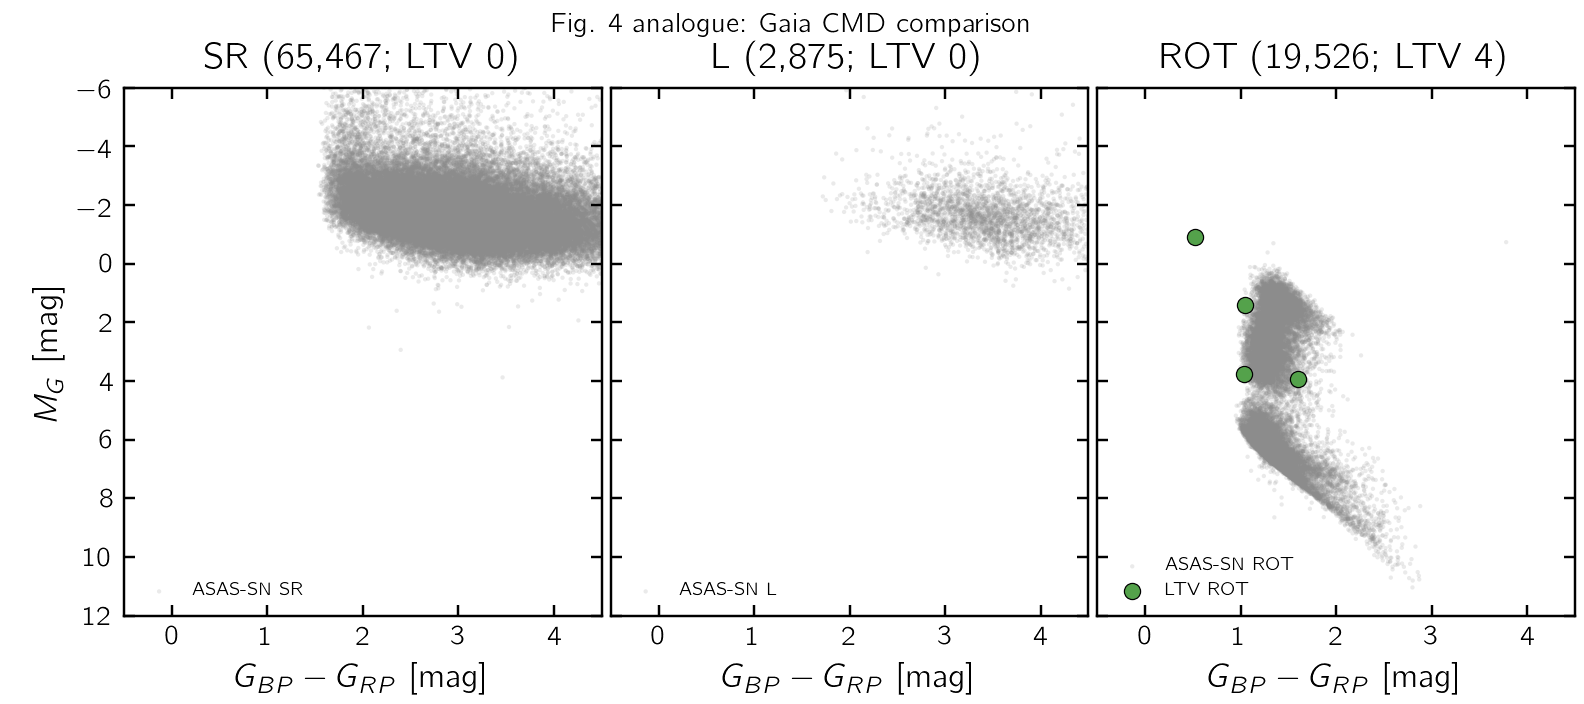

{'png': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig04_ltv_cmd_sr_l_rot.png',
 'pdf': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig04_ltv_cmd_sr_l_rot.pdf',
 'csv': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig04_ltv_cmd_sr_l_rot.csv',
 'table_rows': 87872,
 'caveats': ['No reviewed LTV points with finite CMD coordinates and known SR classification.',
  'No reviewed LTV points with finite CMD coordinates and known L classification.']}

In [5]:

fig4_name = "fig04_ltv_cmd_sr_l_rot"
fig4_rows: list[pd.DataFrame] = []

fig, axes = plt.subplots(1, 3, figsize=(7.2, 3.2), sharex=True, sharey=True)
for ax, cls in zip(axes, CLASS_ORDER):
    bg = asas_cmd[asas_cmd["known_var_class"].eq(cls)].copy()
    bg = bg[np.isfinite(bg["cmd_color"]) & np.isfinite(bg["cmd_mag"])]
    overlay = ltv[ltv["known_var_class"].eq(cls)].copy()
    overlay = overlay[np.isfinite(overlay["cmd_color"]) & np.isfinite(overlay["cmd_mag"])]

    ax.scatter(bg["cmd_color"], bg["cmd_mag"], s=2.0, c=COMPARISON_COLOR, alpha=0.18, edgecolors="none", rasterized=True, label=f"ASAS-SN {cls}")
    if not overlay.empty:
        scatter_with_uncertainty(
            ax,
            overlay,
            "cmd_color",
            "cmd_mag",
            xerr_col="cmd_color_err",
            yerr_col="cmd_mag_err",
            scatter_kwargs={"s": 28, "marker": "o", "c": CLASS_COLORS[cls], "edgecolors": "black", "linewidths": 0.4, "label": f"LTV {cls}", "zorder": 4},
            errorbar_kwargs={"ecolor": "0.25", "elinewidth": 0.6, "alpha": 0.8, "zorder": 3},
        )
    ax.set_title(f"{cls} ({len(bg):,}; LTV {len(overlay)})")
    ax.set_xlabel(r"$G_{BP} - G_{RP}$ [mag]")
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(frameon=False, fontsize=6, loc="lower left")

    fig4_rows.append(bg.assign(source="asassn_variables", panel_class=cls)[["source", "panel_class", "ID", "ML_classification", "cmd_color", "cmd_color_err", "cmd_mag", "cmd_mag_err", "Period"]])
    if not overlay.empty:
        fig4_rows.append(overlay.assign(source="reviewed_ltv", panel_class=cls)[["source", "panel_class", "candidate_id", "known_var_class_source", "cmd_color", "cmd_color_err", "cmd_mag", "cmd_mag_err", "period_days"]])

axes[0].set_ylabel(r"$M_G$ [mag]")
for ax in axes:
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(12.0, -6.0)

fig.suptitle("Fig. 4 analogue: Gaia CMD comparison", fontsize=9)
fig.tight_layout()
fig4_table = pd.concat(fig4_rows, ignore_index=True, sort=False) if fig4_rows else pd.DataFrame()
fig4_result = save_figure(fig, fig4_name, fig4_table)
for cls in CLASS_ORDER:
    if not (ltv["known_var_class"].eq(cls) & np.isfinite(ltv["cmd_color"]) & np.isfinite(ltv["cmd_mag"])).any():
        record_caveat(fig4_name, f"No reviewed LTV points with finite CMD coordinates and known {cls} classification.")
fig4_result


## Fig. 5 Analogue: Slope Distributions for SR/L/ROT

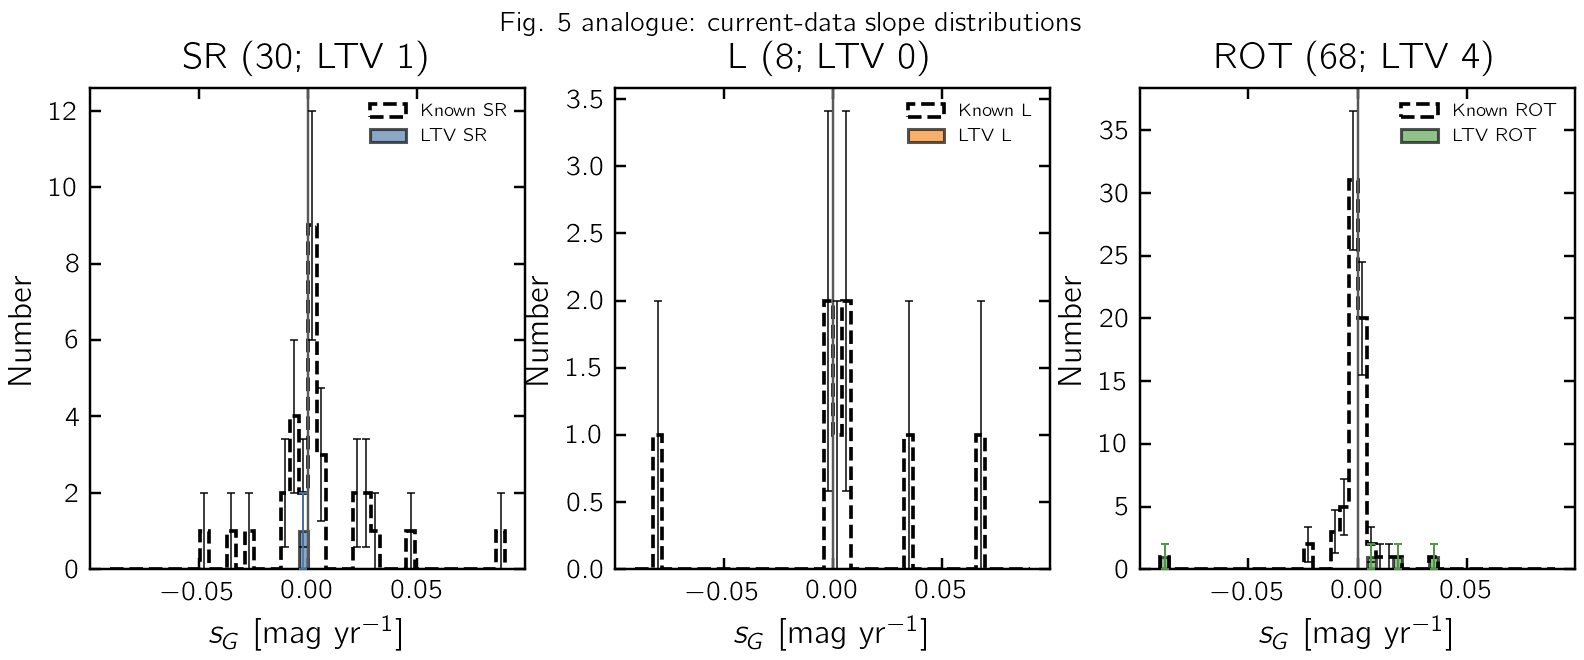

{'png': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig05_ltv_slope_sr_l_rot.png',
 'pdf': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig05_ltv_slope_sr_l_rot.pdf',
 'csv': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig05_ltv_slope_sr_l_rot.csv',
 'table_rows': 111}

In [6]:

fig5_name = "fig05_ltv_slope_sr_l_rot"
fig5_rows: list[pd.DataFrame] = []
reviewed_for_classes = reviewed[reviewed["known_var_class"].isin(CLASS_ORDER)].copy()
all_slopes = pd.to_numeric(reviewed_for_classes["optical_slope"], errors="coerce")
lim = float(np.nanpercentile(all_slopes.abs(), 99.0)) if all_slopes.notna().any() else 0.1
lim = max(0.05, min(lim, 2.0))
bins = np.linspace(-lim, lim, 45)

fig, axes = plt.subplots(1, 3, figsize=(7.2, 3.0), sharex=True, sharey=False)
for ax, cls in zip(axes, CLASS_ORDER):
    comparison = reviewed_for_classes[reviewed_for_classes["known_var_class"].eq(cls)].copy()
    overlay = ltv[ltv["known_var_class"].eq(cls)].copy()
    comp_vals = pd.to_numeric(comparison["optical_slope"], errors="coerce").dropna()
    overlay_vals = pd.to_numeric(overlay["optical_slope"], errors="coerce").dropna()
    plot_hist_with_count_uncertainty(ax, comp_vals.clip(lower=bins[0], upper=bins[-1]), bins, hist_kwargs={"histtype": "step", "color": "black", "linestyle": "--", "linewidth": 1.2, "label": f"Known {cls}"}, error_color="black", error_alpha=0.75)
    plot_hist_with_count_uncertainty(ax, overlay_vals.clip(lower=bins[0], upper=bins[-1]), bins, hist_kwargs={"histtype": "stepfilled", "color": CLASS_COLORS[cls], "alpha": 0.65, "edgecolor": "black", "label": f"LTV {cls}"}, error_color=CLASS_COLORS[cls], error_alpha=0.9)
    ax.axvline(0.0, color="0.35", linewidth=0.8)
    ax.set_title(f"{cls} ({len(comparison):,}; LTV {len(overlay)})")
    ax.set_xlabel(r"$s_G$ [mag yr$^{-1}$]")
    ax.set_ylabel("Number")
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(frameon=False, fontsize=6)
    if comparison.empty:
        record_caveat(fig5_name, f"No current March 18 comparison rows normalize to {cls}.")
    if overlay.empty:
        record_caveat(fig5_name, f"No reviewed LTV rows normalize to {cls}.")
    fig5_rows.append(comparison.assign(source="reviewed_known_class", panel_class=cls)[["source", "panel_class", "candidate_id", "known_var_class", "known_var_class_source", "optical_slope", "optical_slope_err"]])
    fig5_rows.append(overlay.assign(source="reviewed_ltv", panel_class=cls)[["source", "panel_class", "candidate_id", "known_var_class", "known_var_class_source", "optical_slope", "optical_slope_err"]])

fig.suptitle("Fig. 5 analogue: current-data slope distributions", fontsize=9)
fig.tight_layout()
fig5_table = pd.concat(fig5_rows, ignore_index=True, sort=False) if fig5_rows else pd.DataFrame()
fig5_result = save_figure(fig, fig5_name, fig5_table)
fig5_result


## Fig. 7 Analogue: Phased LTV Examples

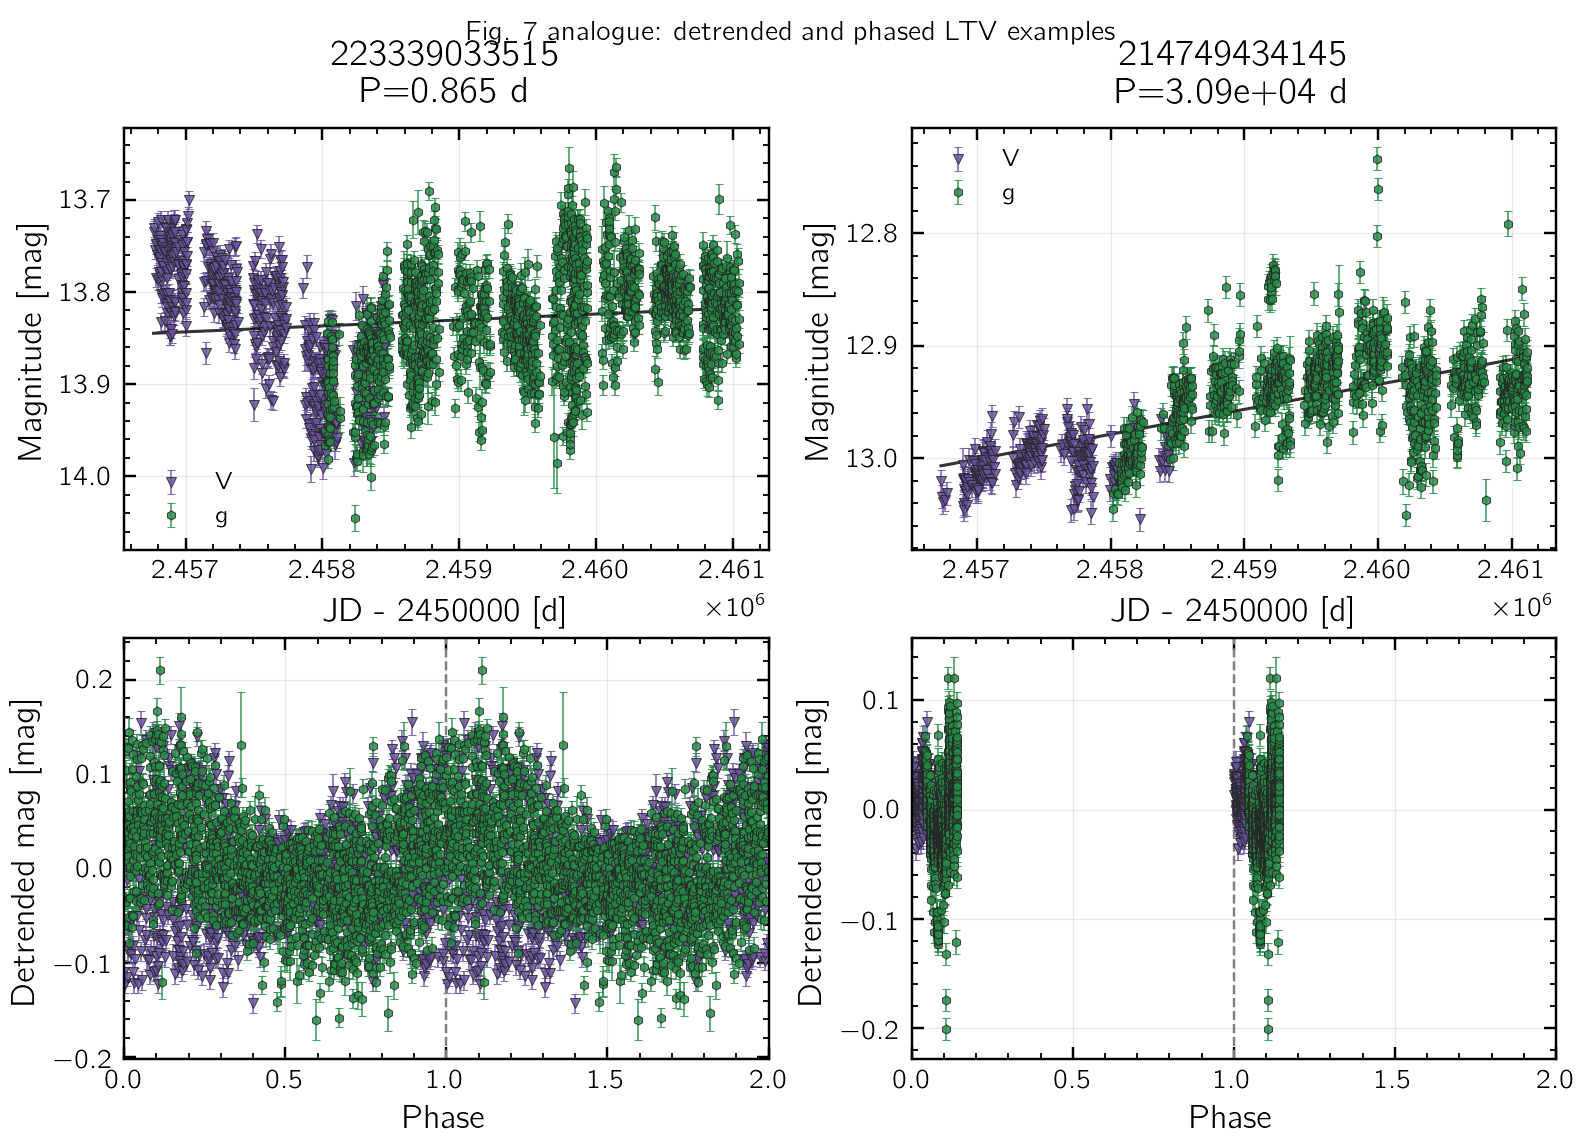

{'png': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig07_ltv_phased_examples.png',
 'pdf': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig07_ltv_phased_examples.pdf',
 'csv': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig07_ltv_phased_examples.csv',
 'table_rows': 10692,
 'selected_candidates': [{'candidate_id': '223339033515',
   'period_days': 0.8651950598246667,
   'selection_reason': 'shortest finite period with ASAS-SN light curve'},
  {'candidate_id': '214749434145',
   'period_days': 30937.805300000007,
   'selection_reason': 'longest finite period with ASAS-SN light curve'}]}

In [7]:

def existing_period_ltv() -> pd.DataFrame:
    out = ltv[np.isfinite(ltv["period_days"]) & (ltv["period_days"] > 0)].copy()
    out["has_lightcurve"] = out["candidate_id"].map(lambda cid: candidate_lc_path(cid).exists())
    return out[out["has_lightcurve"]].sort_values("period_days")


def select_fig7_examples() -> pd.DataFrame:
    if FIG7_EXAMPLE_IDS:
        wanted = [str(cid) for cid in FIG7_EXAMPLE_IDS]
        out = ltv[ltv["candidate_id"].astype(str).isin(wanted)].copy()
        out["selection_reason"] = "manual_override"
        return out
    pool = existing_period_ltv()
    if pool.empty:
        return pool.assign(selection_reason=pd.Series(dtype="string"))
    chosen = []
    shortest = pool.iloc[0].copy()
    shortest["selection_reason"] = "shortest finite period with ASAS-SN light curve"
    chosen.append(shortest)
    if len(pool) > 1:
        longest = pool.iloc[-1].copy()
        longest["selection_reason"] = "longest finite period with ASAS-SN light curve"
        if str(longest["candidate_id"]) != str(shortest["candidate_id"]):
            chosen.append(longest)
    return pd.DataFrame(chosen)


fig7_name = "fig07_ltv_phased_examples"
fig7_examples = select_fig7_examples()
fig7_point_tables: list[pd.DataFrame] = []

if fig7_examples.empty:
    fig, ax = plt.subplots(figsize=(5.0, 2.5))
    ax.text(0.5, 0.5, "No period-bearing LTV examples with local light curves", ha="center", va="center")
    ax.set_axis_off()
    record_caveat(fig7_name, "No period-bearing LTV examples with existing ASAS-SN light curves were available.")
else:
    n = len(fig7_examples)
    fig, axes = plt.subplots(2, n, figsize=(3.6 * n, 5.2), squeeze=False)
    for col_idx, (_, row) in enumerate(fig7_examples.iterrows()):
        cid = str(row["candidate_id"])
        period = float(row["period_days"])
        lc_raw = load_asassn_lc(cid)
        lc_det, (slope_per_day, intercept) = fit_linear_detrend(lc_raw)
        folded = phase_fold_lc(lc_det, period)

        ax_top = axes[0, col_idx]
        ax_phase = axes[1, col_idx]
        plot_lightcurve_panel(
            ax_top,
            lc_det,
            time_col="time",
            value_col="value",
            error_col="value_error",
            band_col="band",
            camera_col="camera",
            group_by="band",
            show_errorbars=True,
            legend="auto",
            marker_size=3.0,
            title=f"{cid}\nP={period:.3g} d",
            xlabel="JD - 2450000 [d]",
            ylabel="Magnitude [mag]",
        )
        ax_top.plot(lc_det["time"], lc_det["trend_mag"], color="black", linewidth=1.0, alpha=0.8)

        plot_lightcurve_panel(
            ax_phase,
            folded,
            time_col="phase",
            value_col="detrended_mag",
            error_col="value_error",
            band_col="band",
            camera_col="camera",
            group_by="band",
            show_errorbars=True,
            legend="none",
            marker_size=3.0,
            title=None,
            xlabel="Phase",
            ylabel="Detrended mag [mag]",
            xlim=(0.0, 2.0),
        )
        ax_phase.axvline(1.0, color="0.5", linestyle="--", linewidth=0.8)
        ax_phase.invert_yaxis()

        time_table = lc_det[["time", "value", "value_error", "band", "camera", "trend_mag", "detrended_mag"]].copy()
        time_table["candidate_id"] = cid
        time_table["period_days"] = period
        time_table["selection_reason"] = row.get("selection_reason")
        time_table["panel"] = "time"
        phase_table = folded[["phase", "detrended_mag", "value_error", "band", "camera"]].copy()
        phase_table["candidate_id"] = cid
        phase_table["period_days"] = period
        phase_table["selection_reason"] = row.get("selection_reason")
        phase_table["panel"] = "phase"
        fig7_point_tables.extend([time_table, phase_table])

    fig.suptitle("Fig. 7 analogue: detrended and phased LTV examples", fontsize=9)
    fig.tight_layout()

fig7_table = pd.concat(fig7_point_tables, ignore_index=True, sort=False) if fig7_point_tables else fig7_examples.copy()
fig7_result = save_figure(fig, fig7_name, fig7_table)
fig7_result["selected_candidates"] = fig7_examples[["candidate_id", "period_days", "selection_reason"]].to_dict("records") if not fig7_examples.empty else []
SUMMARY["figures"][fig7_name] = fig7_result
fig7_result


## Fig. 8 Analogue: Period Distributions for SR/L/ROT

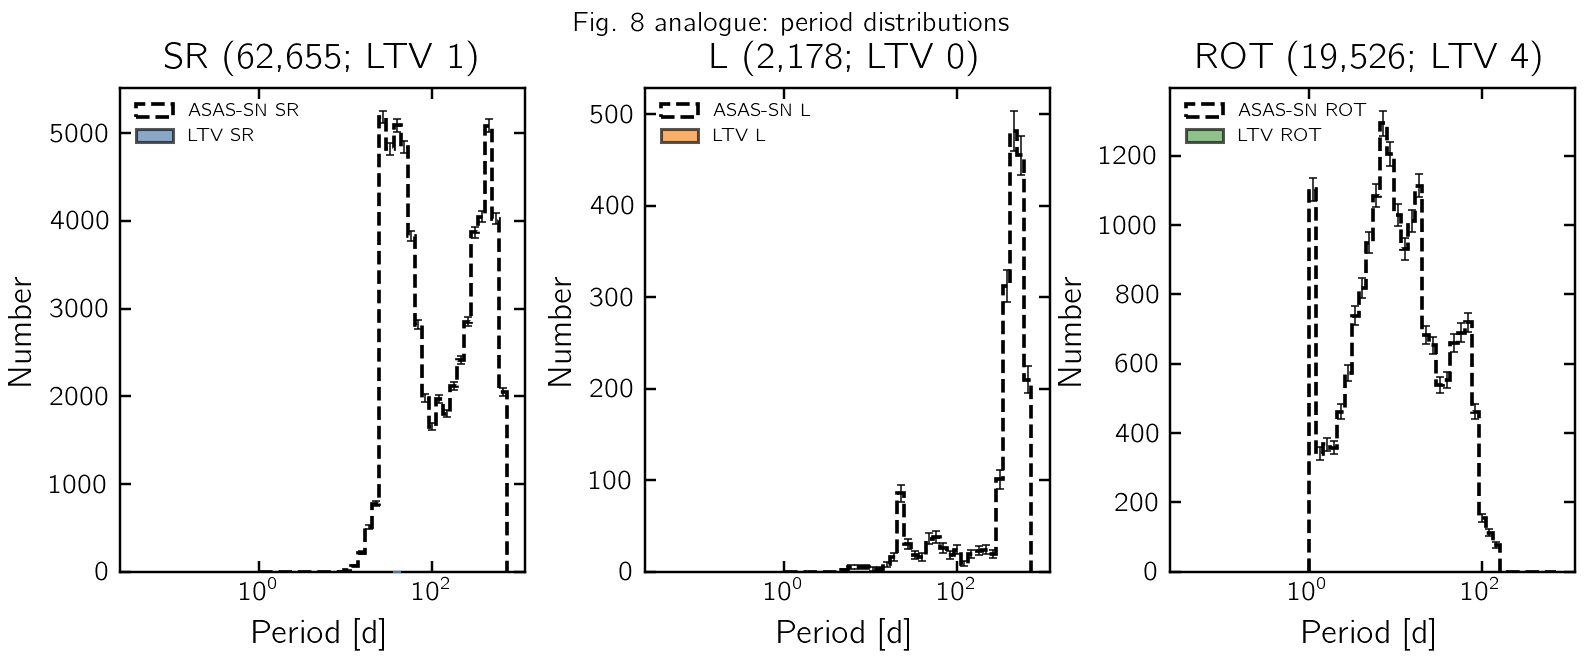

{'png': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig08_ltv_period_sr_l_rot.png',
 'pdf': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig08_ltv_period_sr_l_rot.pdf',
 'csv': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig08_ltv_period_sr_l_rot.csv',
 'table_rows': 84364}

In [8]:

fig8_name = "fig08_ltv_period_sr_l_rot"
fig8_rows: list[pd.DataFrame] = []
period_catalog = asas_cmd[np.isfinite(pd.to_numeric(asas_cmd["Period"], errors="coerce")) & (pd.to_numeric(asas_cmd["Period"], errors="coerce") > 0)].copy()
period_ltv = ltv[np.isfinite(ltv["period_days"]) & (ltv["period_days"] > 0)].copy()
all_period_values = pd.concat([
    pd.to_numeric(period_catalog["Period"], errors="coerce"),
    pd.to_numeric(period_ltv["period_days"], errors="coerce"),
]).dropna()
if all_period_values.empty:
    period_bins = np.logspace(0, 3, 35)
else:
    low = max(0.1, float(np.nanpercentile(all_period_values, 1.0)))
    high = max(low * 10.0, float(np.nanpercentile(all_period_values, 99.0)))
    period_bins = np.logspace(np.log10(low), np.log10(high), 36)

fig, axes = plt.subplots(1, 3, figsize=(7.2, 3.0), sharex=True, sharey=False)
for ax, cls in zip(axes, CLASS_ORDER):
    comp = period_catalog[period_catalog["known_var_class"].eq(cls)].copy()
    overlay = period_ltv[period_ltv["known_var_class"].eq(cls)].copy()
    comp_period = pd.to_numeric(comp["Period"], errors="coerce").dropna()
    overlay_period = pd.to_numeric(overlay["period_days"], errors="coerce").dropna()
    plot_hist_with_count_uncertainty(ax, comp_period, period_bins, hist_kwargs={"histtype": "step", "linestyle": "--", "color": "black", "linewidth": 1.2, "label": f"ASAS-SN {cls}"}, error_color="black", error_alpha=0.75)
    plot_hist_with_count_uncertainty(ax, overlay_period, period_bins, hist_kwargs={"histtype": "stepfilled", "color": CLASS_COLORS[cls], "alpha": 0.65, "edgecolor": "black", "label": f"LTV {cls}"}, error_color=CLASS_COLORS[cls], error_alpha=0.9)
    ax.set_xscale("log")
    ax.set_title(f"{cls} ({len(comp_period):,}; LTV {len(overlay_period)})")
    ax.set_xlabel("Period [d]")
    ax.set_ylabel("Number")
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(frameon=False, fontsize=6)
    if overlay_period.empty:
        record_caveat(fig8_name, f"No reviewed LTV rows normalize to {cls} with finite period_days.")
    fig8_rows.append(comp.assign(source="asassn_variables", panel_class=cls)[["source", "panel_class", "ID", "ML_classification", "Period"]])
    fig8_rows.append(overlay.assign(source="reviewed_ltv", panel_class=cls)[["source", "panel_class", "candidate_id", "known_var_class", "known_var_class_source", "period_days", "period_fap"]])

fig.suptitle("Fig. 8 analogue: period distributions", fontsize=9)
fig.tight_layout()
fig8_table = pd.concat(fig8_rows, ignore_index=True, sort=False) if fig8_rows else pd.DataFrame()
fig8_result = save_figure(fig, fig8_name, fig8_table)
fig8_result


## Fig. 9 Analogue: WISE Dust Diagnostics

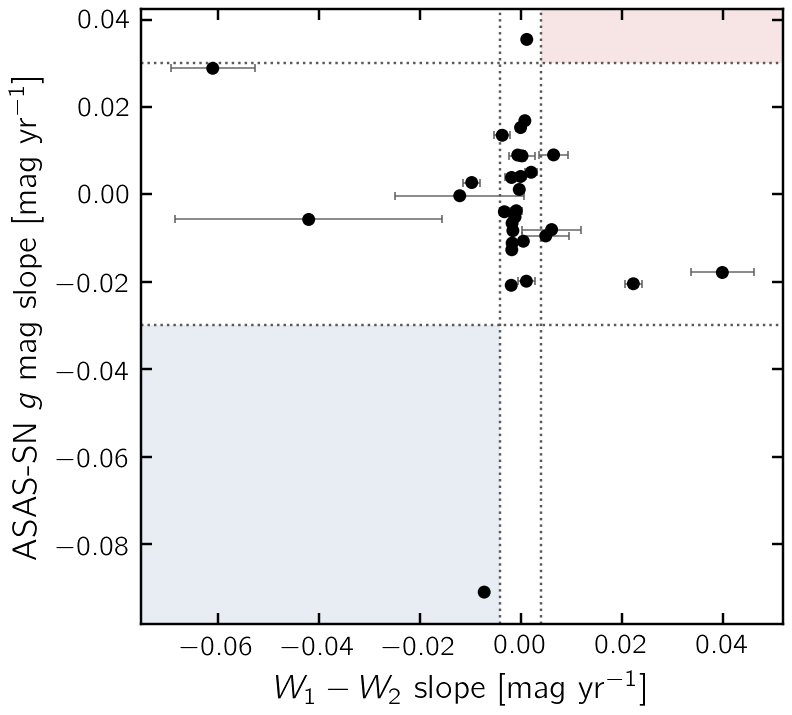

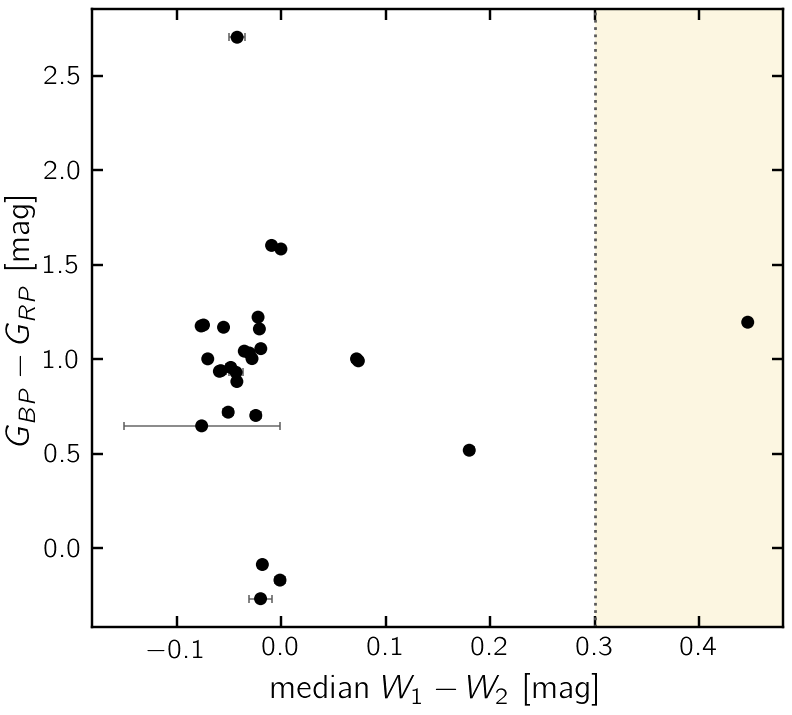

{'slope_panel': {'png': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig09a_ltv_wise_slope_diagnostics.png',
  'pdf': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig09a_ltv_wise_slope_diagnostics.pdf',
  'csv': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig09a_ltv_wise_slope_diagnostics.csv',
  'table_rows': 39,
  'n_ltv': 39,
  'n_neowise_ok': 31},
 'color_panel': {'png': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig09b_ltv_wise_color_diagnostics.png',
  'pdf': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig09b_ltv_wise_color_diagnostics.pdf',
  'csv': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig09b_ltv_wise_color_diagnostics.csv',
  'table_rows': 39,
  'n_ltv': 39,
  'n_neowise_ok': 31}}

In [9]:

fig9_slope_name = "fig09a_ltv_wise_slope_diagnostics"
fig9_color_name = "fig09b_ltv_wise_color_diagnostics"
wise = neowise_metrics.copy()
wise["w1w2_slope"] = pd.to_numeric(wise["ltv_neowise_w1_w2_slope"], errors="coerce")
wise["w1w2_median"] = pd.to_numeric(wise["ltv_neowise_w1_w2_median"], errors="coerce")
wise["optical_slope"] = pd.to_numeric(wise["optical_slope"], errors="coerce")
wise["cmd_color"] = pd.to_numeric(wise["cmd_color"], errors="coerce")
for _err_col in ["w1w2_slope_err", "w1w2_median_err", "optical_slope_err", "cmd_color_err"]:
    if _err_col in wise.columns:
        wise[_err_col] = positive_uncertainty(wise[_err_col])
    else:
        wise[_err_col] = pd.Series(np.nan, index=wise.index, dtype="float64")
left = wise[np.isfinite(wise["w1w2_slope"]) & np.isfinite(wise["optical_slope"])]
right = wise[np.isfinite(wise["cmd_color"]) & np.isfinite(wise["w1w2_median"])]

fig_slope, ax = plt.subplots(figsize=(3.6, 3.25))
ax.axhline(LTV_DUST_OPTICAL_SLOPE_THRESH, color="0.35", linestyle=":", linewidth=0.8)
ax.axhline(-LTV_DUST_OPTICAL_SLOPE_THRESH, color="0.35", linestyle=":", linewidth=0.8)
ax.axvline(LTV_DUST_COLOR_SLOPE_THRESH, color="0.35", linestyle=":", linewidth=0.8)
ax.axvline(-LTV_DUST_COLOR_SLOPE_THRESH, color="0.35", linestyle=":", linewidth=0.8)
scatter_with_uncertainty(ax, left, "w1w2_slope", "optical_slope", xerr_col="w1w2_slope_err", yerr_col="optical_slope_err", scatter_kwargs={"s": 18, "c": "black", "edgecolors": "none", "zorder": 3}, errorbar_kwargs={"ecolor": "0.35", "elinewidth": 0.6, "alpha": 0.75, "zorder": 2})
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.fill_between([LTV_DUST_COLOR_SLOPE_THRESH, x_max], LTV_DUST_OPTICAL_SLOPE_THRESH, y_max, color="#C43C39", alpha=0.13, linewidth=0, zorder=0)
ax.fill_between([x_min, -LTV_DUST_COLOR_SLOPE_THRESH], y_min, -LTV_DUST_OPTICAL_SLOPE_THRESH, color="#4C78A8", alpha=0.13, linewidth=0, zorder=0)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r"$W_1 - W_2$ slope [mag yr$^{-1}$]")
ax.set_ylabel(r"ASAS-SN $g$ mag slope [mag yr$^{-1}$]")
ax.tick_params(direction="in", top=True, right=True)
fig_slope.subplots_adjust(left=0.2, right=0.98, bottom=0.2, top=0.98)
fig9_table = wise.copy()
fig9_slope_result = save_figure(fig_slope, fig9_slope_name, fig9_table)
fig9_slope_result.update({
    "n_ltv": int(len(wise)),
    "n_neowise_ok": int((wise["neowise_status"] == "ok").sum()),
})
SUMMARY["figures"][fig9_slope_name] = fig9_slope_result

fig_color, ax = plt.subplots(figsize=(3.6, 3.25))
scatter_with_uncertainty(ax, right, "w1w2_median", "cmd_color", xerr_col="w1w2_median_err", yerr_col="cmd_color_err", scatter_kwargs={"s": 18, "c": "black", "edgecolors": "none", "zorder": 3}, errorbar_kwargs={"ecolor": "0.35", "elinewidth": 0.6, "alpha": 0.75, "zorder": 2})
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.axvspan(LTV_DUST_COLOR_EXCESS_THRESH, x_max, color="#F2CF5B", alpha=0.18, linewidth=0, zorder=0)
ax.axvline(LTV_DUST_COLOR_EXCESS_THRESH, color="0.35", linestyle=":", linewidth=0.9, zorder=2)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r"median $W_1 - W_2$ [mag]")
ax.set_ylabel(r"$G_{BP} - G_{RP}$ [mag]")
ax.yaxis.set_label_coords(-0.08, 0.5)
ax.tick_params(direction="in", top=True, right=True)
fig_color.subplots_adjust(left=0.18, right=0.98, bottom=0.2, top=0.98)
fig9_color_result = save_figure(fig_color, fig9_color_name, fig9_table)
fig9_color_result.update({
    "n_ltv": int(len(wise)),
    "n_neowise_ok": int((wise["neowise_status"] == "ok").sum()),
})
SUMMARY["figures"][fig9_color_name] = fig9_color_result
{"slope_panel": fig9_slope_result, "color_panel": fig9_color_result}


## Fig. 10 Analogue: ASAS-SN and WISE Example Light Curves

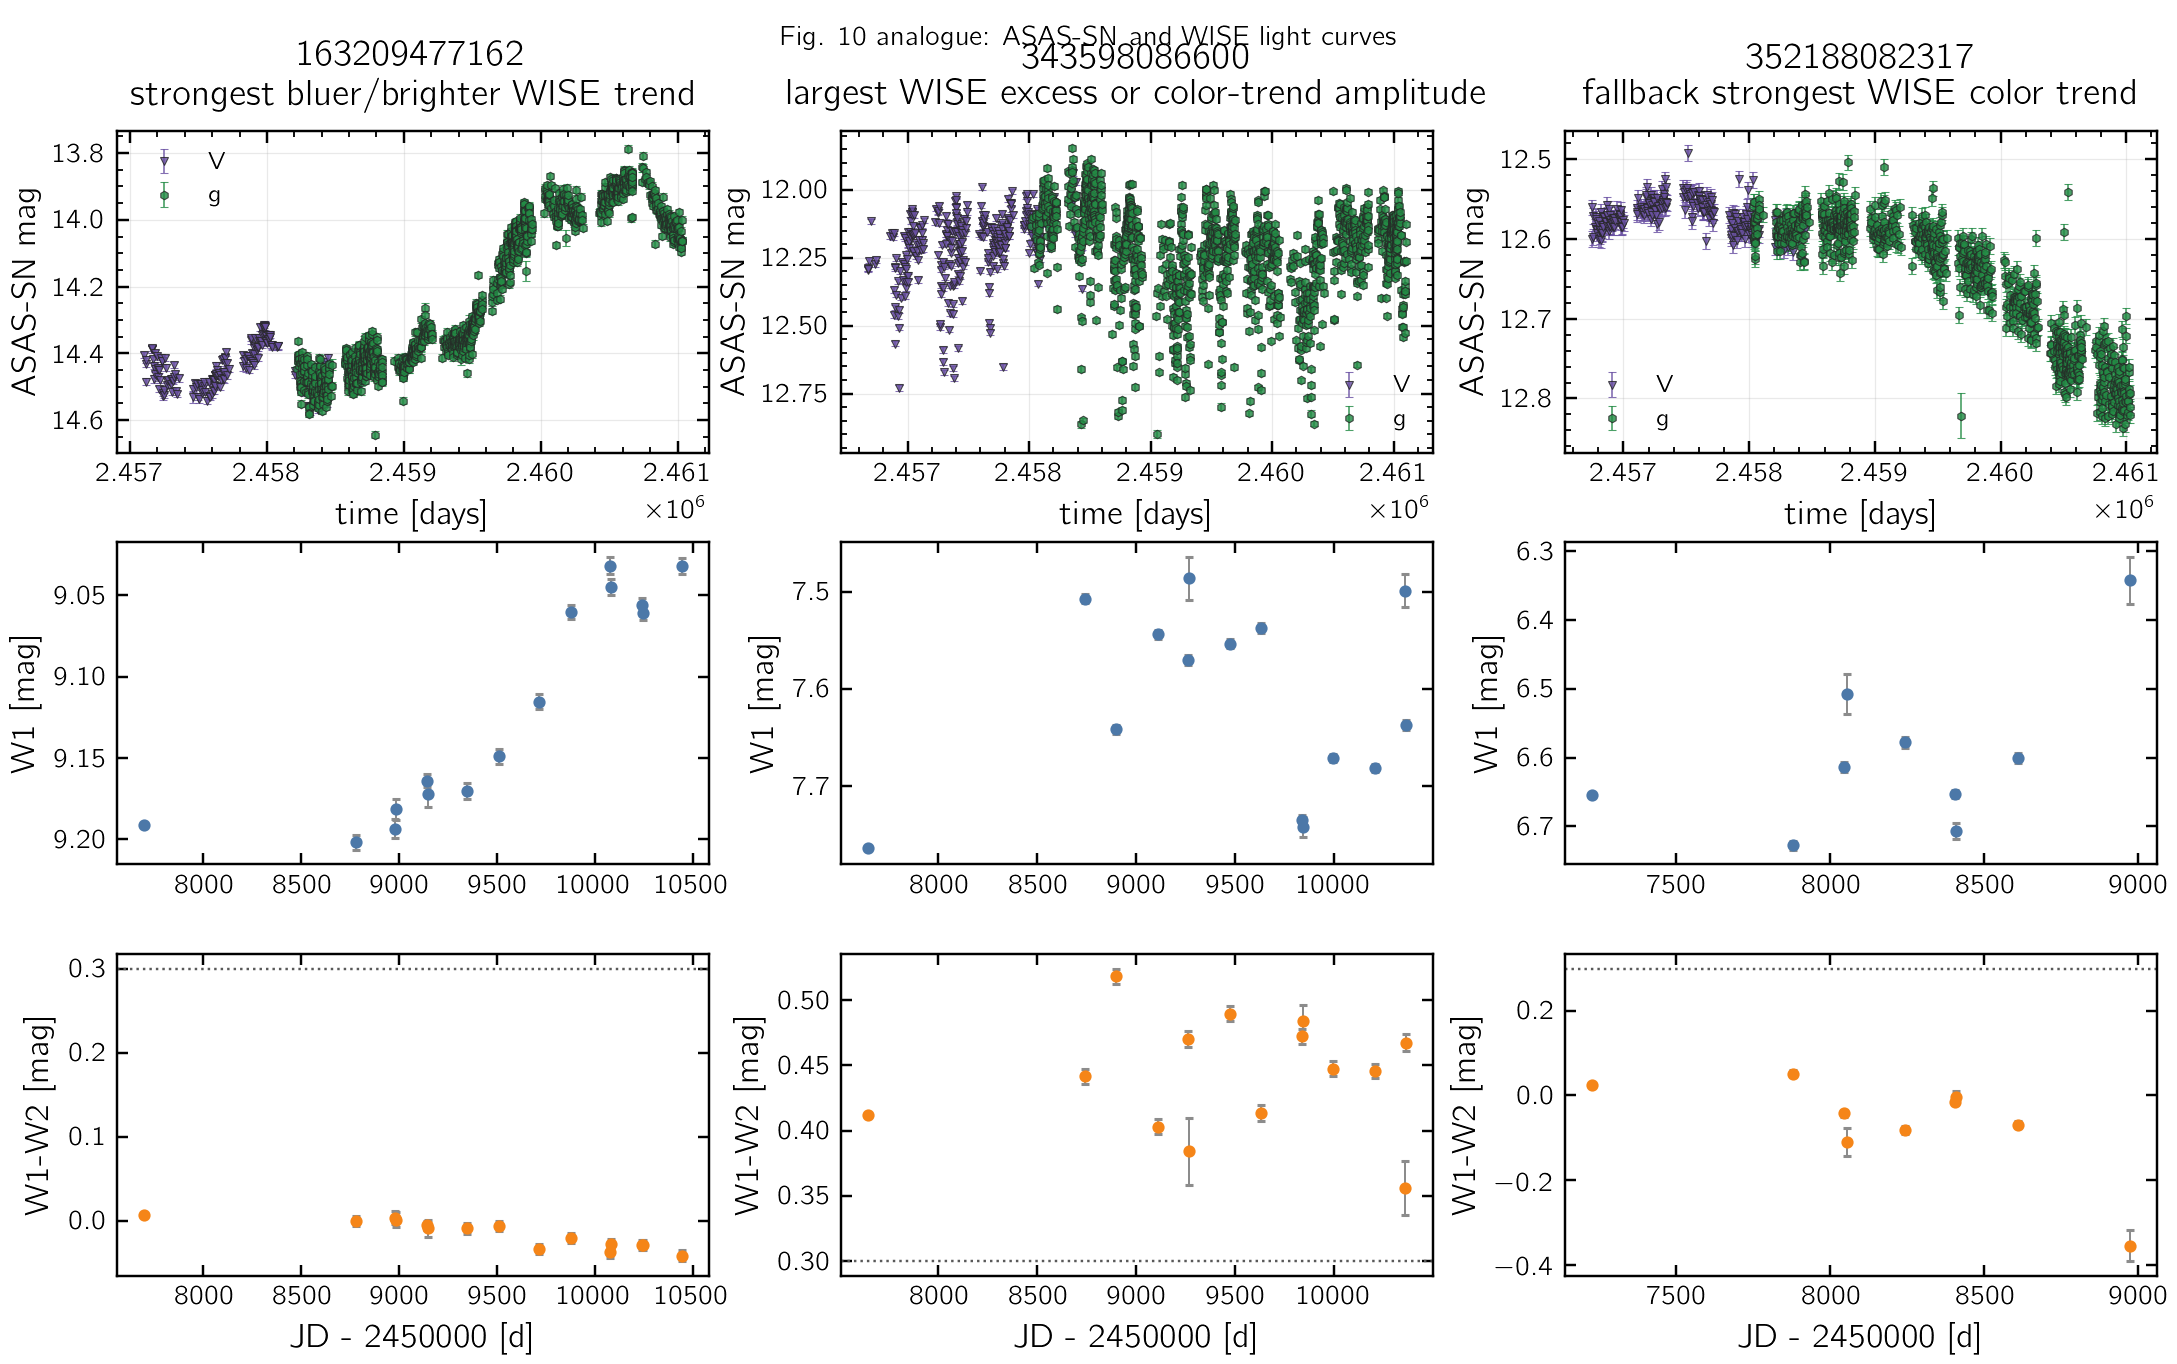

{'png': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig10_ltv_asassn_wise_examples.png',
 'pdf': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig10_ltv_asassn_wise_examples.pdf',
 'csv': 'output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig10_ltv_asassn_wise_examples.csv',
 'table_rows': 4711,
 'selected_candidates': [{'candidate_id': '163209477162',
   'selection_reason': 'strongest bluer/brighter WISE trend',
   'optical_slope': -0.0910347616719865,
   'w1w2_slope': -0.007208897390264547,
   'w1w2_median': -0.009212493896484375},
  {'candidate_id': '343598086600',
   'selection_reason': 'largest WISE excess or color-trend amplitude',
   'optical_slope': 0.008814496566124413,
   'w1w2_slope': 0.0002746978250141892,
   'w1w2_median': 0.44653749465942383},
  {'candidate_id': '352188082317',
   'selection_reason': 'fallback strongest WISE color trend',
   'optical_slope': 0.028865275902685564,
   'w1w2_slope': -0.06094598021666664,
   'w1

In [10]:

def choose_best_row(pool: pd.DataFrame, score: pd.Series, reason: str, used: set[str]) -> dict[str, object] | None:
    tmp = pool.copy()
    tmp["score"] = score.reindex(tmp.index)
    tmp = tmp[np.isfinite(tmp["score"])].sort_values("score", ascending=False)
    for _, row in tmp.iterrows():
        cid = str(row["candidate_id"])
        if cid in used:
            continue
        if not candidate_lc_path(cid).exists():
            continue
        used.add(cid)
        out = row.to_dict()
        out["selection_reason"] = reason
        return out
    return None


def select_fig10_examples() -> pd.DataFrame:
    pool = wise[(wise["neowise_status"] == "ok")].copy()
    if FIG10_EXAMPLE_IDS:
        wanted = [str(cid) for cid in FIG10_EXAMPLE_IDS]
        out = pool[pool["candidate_id"].astype(str).isin(wanted)].copy()
        out["selection_reason"] = "manual_override"
        return out
    selected: list[dict[str, object]] = []
    used: set[str] = set()

    redder = pool[(pool["optical_slope"] >= LTV_DUST_OPTICAL_SLOPE_THRESH) & (pool["w1w2_slope"] >= LTV_DUST_COLOR_SLOPE_THRESH)]
    row = choose_best_row(redder, redder["optical_slope"].abs() + redder["w1w2_slope"].abs(), "strongest redder/fainter WISE trend", used)
    if row is not None:
        selected.append(row)

    bluer = pool[(pool["optical_slope"] <= -LTV_DUST_OPTICAL_SLOPE_THRESH) & (pool["w1w2_slope"] <= -LTV_DUST_COLOR_SLOPE_THRESH)]
    row = choose_best_row(bluer, bluer["optical_slope"].abs() + bluer["w1w2_slope"].abs(), "strongest bluer/brighter WISE trend", used)
    if row is not None:
        selected.append(row)

    remaining = pool[~pool["candidate_id"].astype(str).isin(used)].copy()
    if not remaining.empty:
        score = np.maximum(
            pd.to_numeric(remaining["w1w2_median"], errors="coerce").fillna(-np.inf),
            pd.to_numeric(remaining["w1w2_slope"], errors="coerce").abs().fillna(-np.inf),
        )
        row = choose_best_row(remaining, pd.Series(score, index=remaining.index), "largest WISE excess or color-trend amplitude", used)
        if row is not None:
            selected.append(row)

    if len(selected) < 3:
        remaining = pool[~pool["candidate_id"].astype(str).isin(used)].copy()
        score = pd.to_numeric(remaining["w1w2_slope"], errors="coerce").abs()
        while len(selected) < 3 and not remaining.empty:
            row = choose_best_row(remaining, score, "fallback strongest WISE color trend", used)
            if row is None:
                break
            selected.append(row)
            remaining = pool[~pool["candidate_id"].astype(str).isin(used)].copy()
            score = pd.to_numeric(remaining["w1w2_slope"], errors="coerce").abs()

    return pd.DataFrame(selected)


fig10_name = "fig10_ltv_asassn_wise_examples"
fig10_examples = select_fig10_examples()
fig10_tables: list[pd.DataFrame] = []

if fig10_examples.empty:
    fig, ax = plt.subplots(figsize=(5.0, 2.5))
    ax.text(0.5, 0.5, "No LTV examples with cached NEOWISE and ASAS-SN light curves", ha="center", va="center")
    ax.set_axis_off()
    record_caveat(fig10_name, "No LTV examples with cached NEOWISE and ASAS-SN light curves were available.")
else:
    n = len(fig10_examples)
    fig, axes = plt.subplots(3, n, figsize=(3.3 * n, 6.2), squeeze=False, sharex=False)
    for col_idx, (_, row) in enumerate(fig10_examples.iterrows()):
        cid = str(row["candidate_id"])
        asassn = load_asassn_lc(cid)
        epochs, trends = load_neowise_epochs(cid)
        epochs = epochs.copy()
        epochs["plot_time"] = pd.to_numeric(epochs["mjd"], errors="coerce") - 50000.0
        epochs["w1err"] = positive_uncertainty(epochs["w1err"])
        epochs["w2err"] = positive_uncertainty(epochs["w2err"])
        epochs["w1_w2_err"] = combine_uncertainties(epochs["w1err"], epochs["w2err"])

        ax = axes[0, col_idx]
        plot_lightcurve_panel(
            ax,
            asassn,
            time_col="time",
            value_col="value",
            error_col="value_error",
            band_col="band",
            camera_col="camera",
            group_by="band",
            show_errorbars=True,
            legend="auto",
            marker_size=2.8,
            title=f"{cid}\n{row.get('selection_reason')}",
            xlabel="",
            ylabel="ASAS-SN mag",
        )

        ax = axes[1, col_idx]
        ax.errorbar(epochs["plot_time"], epochs["w1mpro"], yerr=epochs["w1err"], fmt="o", ms=3.0, color="#4C78A8", ecolor="0.55", elinewidth=0.65, capsize=1.2)
        ax.set_ylabel("W1 [mag]")
        ax.invert_yaxis()
        ax.tick_params(direction="in", top=True, right=True)

        ax = axes[2, col_idx]
        ax.errorbar(epochs["plot_time"], epochs["w1_w2"], yerr=epochs["w1_w2_err"], fmt="o", ms=3.0, color="#F58518", ecolor="0.55", elinewidth=0.65, capsize=1.2)
        ax.axhline(LTV_DUST_COLOR_EXCESS_THRESH, color="0.35", linestyle=":", linewidth=0.8)
        ax.set_xlabel("JD - 2450000 [d]")
        ax.set_ylabel("W1-W2 [mag]")
        ax.tick_params(direction="in", top=True, right=True)

        asassn_table = asassn[["time", "value", "value_error", "band", "camera"]].copy()
        asassn_table["candidate_id"] = cid
        asassn_table["source"] = "asassn"
        asassn_table["selection_reason"] = row.get("selection_reason")
        wise_table = epochs.copy()
        wise_table["candidate_id"] = cid
        wise_table["source"] = "neowise"
        wise_table["selection_reason"] = row.get("selection_reason")
        fig10_tables.extend([asassn_table, wise_table])

    fig.suptitle("Fig. 10 analogue: ASAS-SN and WISE light curves", fontsize=9)
    fig.tight_layout()

fig10_table = pd.concat(fig10_tables, ignore_index=True, sort=False) if fig10_tables else fig10_examples.copy()
fig10_result = save_figure(fig, fig10_name, fig10_table)
fig10_result["selected_candidates"] = fig10_examples[["candidate_id", "selection_reason", "optical_slope", "w1w2_slope", "w1w2_median"]].to_dict("records") if not fig10_examples.empty else []
SUMMARY["figures"][fig10_name] = fig10_result
fig10_result


## Write Summary

In [11]:

summary_path = OUT_DIR / "figure_generation_summary.json"
summary_path.write_text(json.dumps(SUMMARY, indent=2, sort_keys=True, default=str) + "\n", encoding="utf-8")
print(f"Wrote {summary_path.relative_to(REPO_ROOT)}")
print(json.dumps(SUMMARY, indent=2, sort_keys=True, default=str))


Wrote output/runs/runs_march18_bundle_all/results/ltv_paper_figures/figure_generation_summary.json
{
  "candidate_table": "output/runs/runs_march18_bundle_all/results/lc_events_classified.parquet",
  "caveats": [
    "Current-data analogues only; not exact reconstructions of the full Petz & Kochanek parent sample.",
    "No network fetches are performed; missing Gaia/WISE/catalog data are reported and skipped."
  ],
  "figures": {
    "fig01_ltv_selection_histograms": {
      "caveats": [
        "Background is all current March 18 candidates, not the original 9.36M input-source parent sample."
      ],
      "csv": "output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig01_ltv_selection_histograms.csv",
      "n_all_with_slope": 9569,
      "n_ltv_with_slope": 39,
      "pdf": "output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig01_ltv_selection_histograms.pdf",
      "png": "output/runs/runs_march18_bundle_all/results/ltv_paper_figures/fig01_ltv_selection_histo